In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re


**Ver también `Comparación_Profundidades.ipynb`**

### BOYAS UPCT (CTD**)


In [2]:
path = "boyaUPCT"
filename = "locBoyasUPCT.csv"
loc_boyas = pd.read_csv(os.path.join(path, filename)).iloc[:,:3]
loc_boyas.head(3)
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas_upct = {}
# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    for archivo in archivos_csv:     
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        if nombre_variable in ["Clorofila"]:
            dataframes_boyas_upct[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)
for key, df in dataframes_boyas_upct.items():
    df['Date'] = pd.to_datetime(df['Date'])


In [3]:
def add_average_column(df_dict, depth):
    for name, df in df_dict.items():
        df = df.copy()  # Ensure we don't modify the original data directly
        
        columns = ['0.0', '0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
        
        # Select columns to average (excluding '0.5' and '1.0')
        if depth == ">1":
            cols_to_avg = [col for col in columns if col in df.columns and col not in ['0.0', '0.5', '1.0']]
        if depth == "<1":
            cols_to_avg = [col for col in columns if col in df.columns and col not in ['1.5','2.0','2.5', '3.0', '3.5', '4.0', '4.5', '5.0']]
        if depth == "<2":
            cols_to_avg = [col for col in columns if col in df.columns and col not in ['2.5', '3.0', '3.5', '4.0', '4.5', '5.0']]
        if depth == "=1":
            cols_to_avg = [col for col in columns if col in df.columns and col not in ['0.0', '0.5', '1.5','2.0','2.5', '3.0', '3.5', '4.0', '4.5', '5.0']]
        if depth == "=0":
            cols_to_avg = [col for col in columns if col in df.columns and col not in ['1.0', '1.5','2.0','2.5', '3.0', '3.5', '4.0', '4.5', '5.0']]

        # Compute the mean and add a new column
        if cols_to_avg:
            df['Average'] = df[cols_to_avg].mean(axis=1).round(3)
        
        # Update the dictionary with the modified DataFrame
        df_dict[name] = df

    return df_dict


In [31]:
depth = ">1" # >1, <1, <2
dataframes_boyas_upct = add_average_column(dataframes_boyas_upct, depth)

### BOYAS IMIDA (CTD-E**)


In [4]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyasProf/"
# Listamos los nombres de todas las boyas
buoy_ids = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas_imida = {}
# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    for archivo in archivos_csv:     
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        if nombre_variable in ["Clorofila"]:
            dataframes_boyas_imida[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)
for key, df in dataframes_boyas_imida.items():
    df['fecha'] = pd.to_datetime(df['fecha'])

In [5]:
for key, df in dataframes_boyas_imida.items():
    nuevo_nombre_columnas = {}
    for col in df.columns:
        match = re.search(r'profundidad_(-?\d+\.?\d*)', col)
        if match:
            nuevo_nombre_columnas[col] = str(abs(float(match.group(1))))
    dataframes_boyas_imida[key].rename(columns=nuevo_nombre_columnas, inplace=True)

# Lista de profundidades deseadas como strings
cols_to_keep = ['fecha', '0.0', '1.0', '2.0', '3.0', '4.0', '5.0']

for key, df in dataframes_boyas_imida.items():
    columnas_filtradas = [col for col in df.columns if col in cols_to_keep]
    dataframes_boyas_imida[key] = df[columnas_filtradas]

In [18]:
depth = "<2"
dataframes_boyas_imida = add_average_column(dataframes_boyas_imida, depth)

In [6]:
def create_combined_dataframe(df_dict):
    data = []
    for name in sorted(df_dict.keys()):
        if name.startswith("CTD-E5") or name.startswith("CTD-E9"):
            continue  # Ignore CTD5 and CTD9
        buoy_name = name.split('_')[0]  # Extract buoy name (CTD1, CTD2, etc.)
        df = df_dict[name]
        if 'Average' in df.columns:
            for _, row in df.iterrows():
                data.append({'Date': row['fecha'], 'Buoy': buoy_name, 'Chl': row['Average']})
    combined_df = pd.DataFrame(data).sort_values(by=["Date", "Buoy"])
    combined_df["Buoy"] = combined_df["Buoy"].str.replace(r"CTD-E", "CTD", regex=True)
    return combined_df

df_boyas = create_combined_dataframe(dataframes_boyas_imida)

KeyError: 'Date'

In [20]:
df_boyas

,Date,Buoy,Chl
3200,2016-06-08,CTD8,13.755
2131,2016-06-29,CTD4,11.875
1057,2016-08-02,CTD1,11.845
0,2016-08-02,CTD10,13.015
353,2016-08-02,CTD11,15.070
...,...,...,...
2130,2023-08-24,CTD3,0.470
2488,2023-08-24,CTD4,0.500
2845,2023-08-24,CTD6,0.475
3199,2023-08-24,CTD7,0.430


In [21]:
df_boyas.to_csv("saved_files/df_boyas_imida_depth_lt_2.csv", index=False)

In [34]:
pares = []
for key1 in sorted(dataframes_boyas_imida.keys(), key=lambda x: int(re.search(r'CTD-E(\d+)', x).group(1))):
    num = re.search(r'CTD-E(\d+)', key1).group(1)
    if num == '5' or num == '9':
        continue
    key2 = f"CTD{num}_Clorofila"
    if key2 in dataframes_boyas_upct:
        pares.append((key1, key2))

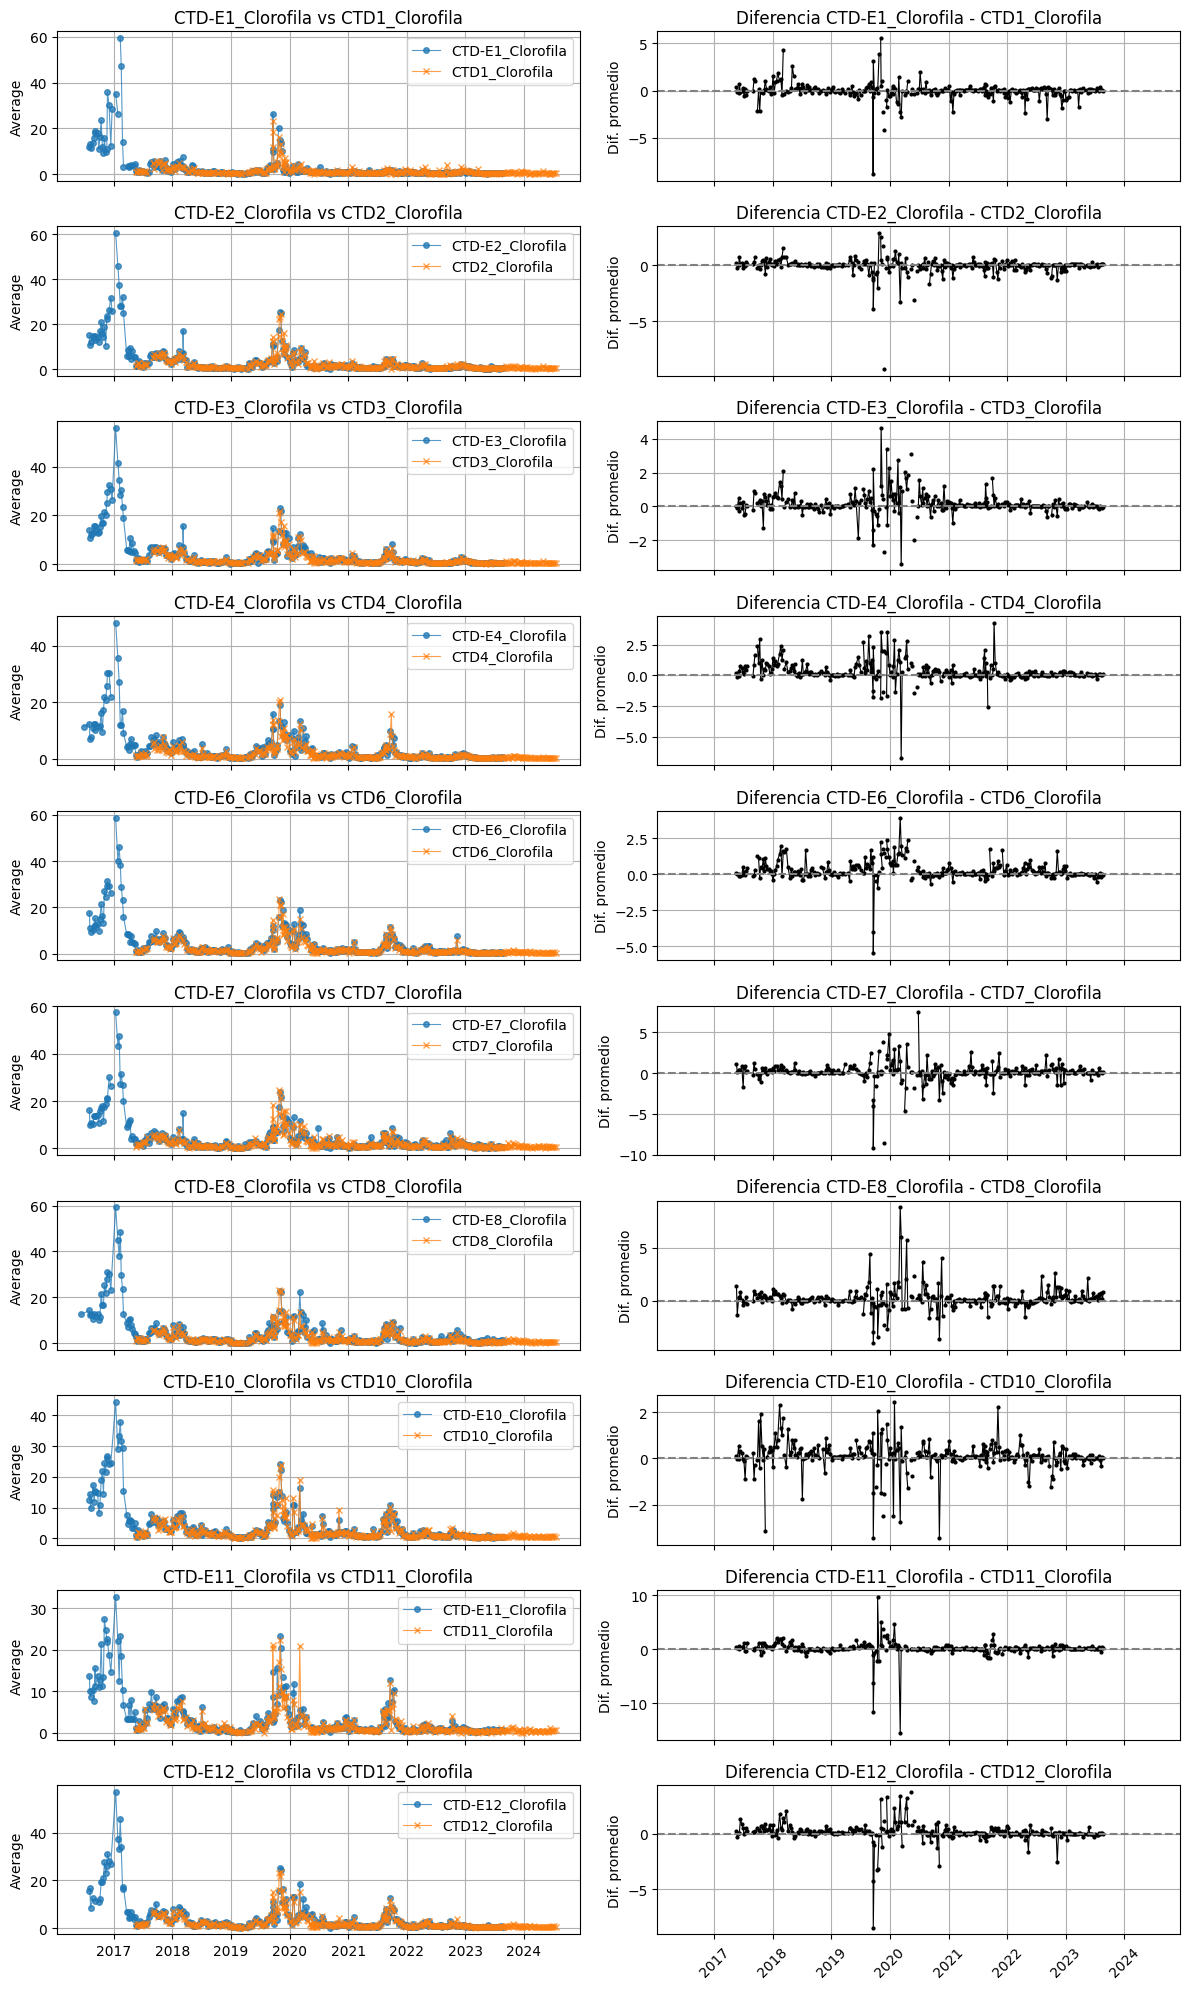

In [35]:
# Crear subplots
fig, axes = plt.subplots(nrows=len(pares), ncols=2, figsize=(12, len(pares)*2), sharex=True)

# Si solo hay un subplot, `axes` no es una lista
if len(pares) == 1:
    axes = [axes]  # Asegurar que axes es iterable

for i, (k1, k2) in enumerate(pares):
    df1 = dataframes_boyas_imida[k1][['fecha', 'Average']].copy()
    df2 = dataframes_boyas_upct[k2][['Date', 'Average']].copy()

    # Convertir a datetime
    df1['fecha'] = pd.to_datetime(df1['fecha'])
    df2['Date'] = pd.to_datetime(df2['Date'])

    # Rango común de fechas (unión)
    fechas_comunes = pd.Series(df1['fecha'].tolist() + df2['Date'].tolist()).drop_duplicates().sort_values()

    # Reindexar
    df1.set_index('fecha', inplace=True)
    df2.set_index('Date', inplace=True)
    df1 = df1.reindex(fechas_comunes)
    df2 = df2.reindex(fechas_comunes)

    # Columna 1: comparación
    ax_cmp = axes[i][0] if len(pares) > 1 else axes[0]
    ax_cmp.plot(fechas_comunes, df1['Average'], label=k1, marker='o', markersize=4, linewidth=0.8, alpha=0.75)
    ax_cmp.plot(fechas_comunes, df2['Average'], label=k2, marker='x', markersize=4, linewidth=0.8, alpha=0.75)
    ax_cmp.set_title(f'{k1} vs {k2}')
    ax_cmp.set_ylabel('Average')
    ax_cmp.legend()
    ax_cmp.grid(True)

    # Columna 2: diferencia
    ax_diff = axes[i][1] if len(pares) > 1 else axes[1]
    diferencia = df1['Average'] - df2['Average']
    ax_diff.plot(fechas_comunes, diferencia, label='Diferencia', color='black', marker='.', markersize=4, linewidth=0.8)
    ax_diff.axhline(0, color='gray', linestyle='--')
    ax_diff.set_title(f'Diferencia {k1} - {k2}')
    ax_diff.set_ylabel('Dif. promedio')
    ax_diff.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()